In [1]:
# Task 1 : Data Preprocessing

In [3]:
import pandas as pd
anime = pd.read_csv("anime.csv")
print(anime.shape)
anime.head()

(12294, 7)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [4]:
anime.info()
anime.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


,anime_id,name,genre,type,episodes,rating,members
count,12294.000000,12294,12232,12269,12294,12064.000000,1.229400e+04
unique,NaN,12292,3264,6,187,NaN,NaN
top,NaN,Saru Kani Gassen,Hentai,TV,1,NaN,NaN
freq,NaN,2,823,3787,5677,NaN,NaN
mean,14058.221653,NaN,NaN,NaN,NaN,6.473902,1.807134e+04
std,11455.294701,NaN,NaN,NaN,NaN,1.026746,5.482068e+04
min,1.000000,NaN,NaN,NaN,NaN,1.670000,5.000000e+00
25%,3484.250000,NaN,NaN,NaN,NaN,5.880000,2.250000e+02
50%,10260.500000,NaN,NaN,NaN,NaN,6.570000,1.550000e+03
75%,24794.500000,NaN,NaN,NaN,NaN,7.180000,9.437000e+03


In [5]:
anime.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [40]:
anime['genre'] = anime['genre'].fillna('Unknown')
anime['type'] = anime['type'].fillna('Unknown')
anime['episodes'] = anime['episodes'].replace('Unknown', np.nan)
anime['episodes'] = pd.to_numeric(anime['episodes'], errors='coerce').fillna(0).astype(int)

In [41]:
anime.isnull().sum()

anime_id      0
name          0
genre         0
type          0
episodes      0
rating        0
members       0
genre_list    0
dtype: int64

In [42]:
print("Number of unique anime:", anime['name'].nunique())
print("Anime types:", anime['type'].unique())
print("Average rating:", anime['rating'].mean())

Number of unique anime: 12292
Anime types: ['Movie' 'TV' 'OVA' 'Special' 'Music' 'ONA']
Average rating: 6.473901690981433


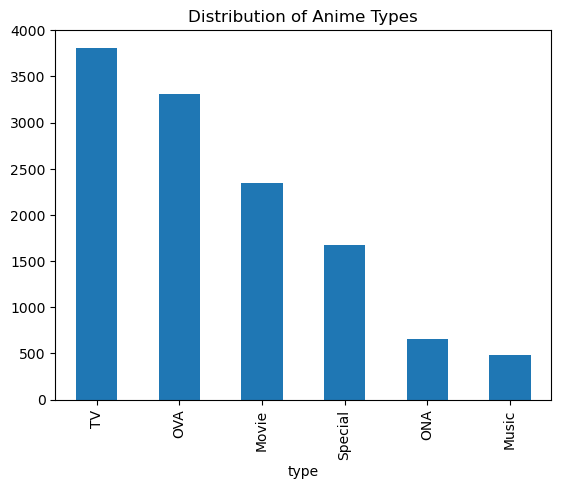

In [43]:
import matplotlib.pyplot as plt
anime['type'].value_counts().plot(kind='bar', title='Distribution of Anime Types')
plt.show()

In [44]:
# Task 2 : Feature Extraction

In [45]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
type_encoded = encoder.fit_transform(anime[['type']]).toarray()
print("Type shape:", type_encoded.shape)

Type shape: (12294, 6)


In [46]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
anime['episodes'] = anime['episodes'].replace('Unknown', np.nan)
anime['episodes'] = pd.to_numeric(anime['episodes'], errors='coerce')
anime['episodes'] = anime['episodes'].fillna(anime['episodes'].median()).astype(int)
scaler = MinMaxScaler()
numeric_features = scaler.fit_transform(anime[['rating', 'episodes']])
print("Numeric shape:", numeric_features.shape)

Numeric shape: (12294, 2)


In [47]:
from sklearn.preprocessing import MultiLabelBinarizer
anime['genre_list'] = anime['genre'].apply(lambda x: x.split(', '))
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(anime['genre_list'])
print("Genre encoded shape:", genre_encoded.shape)

Genre encoded shape: (12294, 43)


In [48]:
anime['rating'] = anime['rating'].fillna(anime['rating'].mean())
anime.isnull().sum()

anime_id      0
name          0
genre         0
type          0
episodes      0
rating        0
members       0
genre_list    0
dtype: int64

In [58]:
# Task 3 : Recommendation System Building

In [49]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack,csr_matrix
genre_encoded = csr_matrix(genre_encoded)
type_encoded = csr_matrix(type_encoded)
numeric_features = csr_matrix(numeric_features)
feature_matrix = hstack([genre_encoded, type_encoded, numeric_features])
print("Final feature matrix shape:", feature_matrix.shape)
cosine_sim = cosine_similarity(feature_matrix, feature_matrix)
print("Cosine similarity matrix shape:", cosine_sim.shape)

Final feature matrix shape: (12294, 51)
Cosine similarity matrix shape: (12294, 12294)


In [53]:
def recommend_anime(title, cosine_sim=cosine_sim, top_n=10, threshold=0.3):
    if title not in anime['name'].values:
        print(f"Anime '{title}' not found in dataset.")
        return []
    idx = anime[anime['name'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [(i, score) for i, score in sim_scores if i != idx]
    top_indices = [i for i, score in sim_scores[:top_n]]
    recommendations = anime.iloc[top_indices][['name', 'genre', 'type', 'rating']].copy()
    recommendations['similarity_score'] = [score for i, score in sim_scores[:top_n]]
    print(f"\n Top {len(recommendations)} anime similar to '{title}':\n")
    return recommendations

In [54]:
recs = recommend_anime("Naruto", top_n=5, threshold=0.25)
print(recs)


 Top 5 anime similar to 'Naruto':

                       name  \
615      Naruto: Shippuuden   
175  Katekyo Hitman Reborn!   
206           Dragon Ball Z   
588         Dragon Ball Kai   
515  Dragon Ball Kai (2014)   

                                                 genre type  rating  \
615  Action, Comedy, Martial Arts, Shounen, Super P...   TV    7.94   
175               Action, Comedy, Shounen, Super Power   TV    8.37   
206  Action, Adventure, Comedy, Fantasy, Martial Ar...   TV    8.32   
588  Action, Adventure, Comedy, Fantasy, Martial Ar...   TV    7.95   
515  Action, Adventure, Comedy, Fantasy, Martial Ar...   TV    8.01   

     similarity_score  
615          0.998885  
175          0.920263  
206          0.876677  
588          0.875267  
515          0.875186  


In [55]:
def recommend_anime_threshold(title, cosine_sim, df, threshold=0.8):
    idx = df.index[df['name'].str.lower() == title.lower()].tolist()
    if not idx:
        print(f"Anime '{title}' not found.")
        return None
    idx = idx[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [(i, score) for i, score in sim_scores if score >= threshold and i != idx]
    if not sim_scores:
        print(f"No anime found above threshold {threshold}. Try lowering it.")
        return None
    recommendations = df.iloc[[i for i, _ in sim_scores]][['name', 'genre', 'type', 'rating']]
    recommendations['similarity_score'] = [score for _, score in sim_scores]
    return recommendations

In [56]:
for t in [0.9, 0.8, 0.7, 0.6]:
    print(f"\n Threshold: {t}")
    result = recommend_anime_threshold('Naruto', cosine_sim, anime, threshold=t)
    if result is not None:
        print(f"{len(result)} recommendations found")
        print(result[['name', 'similarity_score']].head())


 Threshold: 0.9
2 recommendations found
                       name  similarity_score
615      Naruto: Shippuuden          0.998885
175  Katekyo Hitman Reborn!          0.920263

 Threshold: 0.8
32 recommendations found
                       name  similarity_score
615      Naruto: Shippuuden          0.998885
175  Katekyo Hitman Reborn!          0.920263
206           Dragon Ball Z          0.876677
588         Dragon Ball Kai          0.875267
515  Dragon Ball Kai (2014)          0.875186

 Threshold: 0.7
124 recommendations found
                       name  similarity_score
615      Naruto: Shippuuden          0.998885
175  Katekyo Hitman Reborn!          0.920263
206           Dragon Ball Z          0.876677
588         Dragon Ball Kai          0.875267
515  Dragon Ball Kai (2014)          0.875186

 Threshold: 0.6
617 recommendations found
                       name  similarity_score
615      Naruto: Shippuuden          0.998885
175  Katekyo Hitman Reborn!          0.920263
206

In [57]:
avg_sim = cosine_sim.mean()
max_sim = cosine_sim.max()
print(f"Average similarity across all pairs: {avg_sim:.3f}")
print(f"Maximum similarity (excluding self): {max_sim:.3f}")

Average similarity across all pairs: 0.237
Maximum similarity (excluding self): 1.000


In [60]:
# 1. Can you explain the difference between user-based and item-based collaborative filtering?
# --> i) Collaborative Filtering is a recommendation technique that makes predictions about a user’s interests by collecting preferences 
#         (ratings, interactions, etc.) from many users.
#     ii) There are two main types:
#            A. User-Based Collaborative Filtering (UBCF) - It focuses on similarity between users.
#             I]  How It Works:
#                a) It computes similarity between users (e.g., cosine similarity).
#                b) It finds users who are most similar to the target user.
#                c) Example: User A and User B both love Naruto and One Piece. User B also loves Attack on Titan. Recommend Attack on Titan to User A.
#            II] Advantages:
#                a) It is easy to understand.
#                b) It works well with smaller datasets.
#           III] Disadvantages:
#                a) It doesn’t scale well — too many users → huge similarity matrix.
#                b) Users’ preferences can change quickly (less stable).
#           B. Item-Based Collaborative Filtering (IBCF) - It focuses on similarity between items (anime, movies, products, etc.).
#              I] How It Works:
#                 a) It computes similarity between items (based on users’ ratings).
#                 b) For a user, find items similar to the ones they rated highly.
#                 c) Example: Many users who liked Naruto also liked Bleach and One Piece.Recommend Bleach or One Piece to a user who liked Naruto.
#              II] Advantages:
#                 a) It is more stable — item relationships don’t change often.
#                 b) It is easier to scale than user-based CF.
#             III] Disadvantages:
#                 a) It struggles with cold-start problem (new items with no ratings).
#                 b) It doesn’t consider individual user differences much.

In [ ]:
# 2. What is collaborative filtering, and how does it work?
# ---> Collaborative Filtering is a recommendation technique that makes predictions about a user’s interests by collecting preferences 
#       (ratings, interactions, etc.) from many users.
#      It works in two main steps:
#          A] Build a user–item matrix
#          B] Find patterns in the matrix